In [24]:
# =============================================================================
# ASSIGNMENT 1: PORTFOLIO MANAGEMENT & RISK ANALYSIS
# Green, Brown & Mixed NSE Portfolios
# =============================================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

# =============================================================================
# SECTION 0: CONFIGURATION
# =============================================================================

START_DATE = "2021-03-15"
END_DATE   = "2026-03-15"
MARKET     = "^NSEI"             # Nifty 50
RISK_FREE_RATE    = 0.07         # 7% Indian G-Sec
CONFIDENCE_LEVEL  = 0.95         # 95% VaR
PORTFOLIO_VALUE   = 1_000_000    # ₹10,00,000
MC_ITERATIONS     = 1000         # Monte Carlo iterations (single-stock)
MC_T_INTERVALS    = 250          # Trading days to simulate
MC_SIMULATIONS    = 10000        # Monte Carlo simulations (portfolio VaR)

# ---------- Stock Universes ----------
green_tickers = [
    "ADANIGREEN.NS","TATAPOWER.NS", "SUZLON.NS", "SJVN.NS",
    "KPIGREEN.NS",   "NTPC.NS",      "TORNTPOWER.NS", "INOXWIND.NS",
    "CUMMINSIND.NS", "BOSCHLTD.NS"
]

brown_tickers = [
    "RELIANCE.NS", "ONGC.NS",     "COALINDIA.NS", "JSWSTEEL.NS",
    "TATASTEEL.NS", "ULTRACEMCO.NS", "SAIL.NS",      "NMDC.NS",
    "IOC.NS",       "BPCL.NS"
]

mixed_tickers = [
    # 5 Green
    "ADANIGREEN.NS", "TATAPOWER.NS", "SUZLON.NS", "SJVN.NS", "NTPC.NS",
    # 5 Brown
    "RELIANCE.NS",  "ONGC.NS",      "COALINDIA.NS", "JSWSTEEL.NS", "ULTRACEMCO.NS"
]

portfolios = {
    "Green": green_tickers,
    "Brown": brown_tickers,
    "Mixed": mixed_tickers
}

In [25]:
# =============================================================================
# SECTION 1: DATA COLLECTION
# Collect daily stock price data for the last 5 years from Yahoo Finance.
# =============================================================================

print("=" * 65)
print("SECTION 1: DATA COLLECTION")
print("=" * 65)

price_data   = {}   # raw Close prices per portfolio
returns_data = {}   # pct_change returns per portfolio

for name, tickers in portfolios.items():
    print(f"\nDownloading {name} Portfolio...")
    data = yf.download(tickers, start=START_DATE, end=END_DATE)['Close']
    data = data.dropna()
    price_data[name]   = data
    returns_data[name] = data.pct_change().dropna()
    print(f"  {name}: {data.shape[0]} trading days  |  {data.shape[1]} stocks")

print("\nData collection complete.")


SECTION 1: DATA COLLECTION



[*********************100%***********************]  10 of 10 completed
[                       0%                       ]

  Green: 1147 trading days  |  10 stocks



[*********************100%***********************]  10 of 10 completed
[                       0%                       ]

  Brown: 1237 trading days  |  10 stocks



[*********************100%***********************]  10 of 10 completed

  Mixed: 1237 trading days  |  10 stocks

Data collection complete.



SECTION 2: TECHNICAL ANALYSIS

  Green Portfolio — NTPC.NS
  Current Trend : BULLISH (Golden Cross)
  Latest MA-20  : 376.12  |  MA-50: 359.54


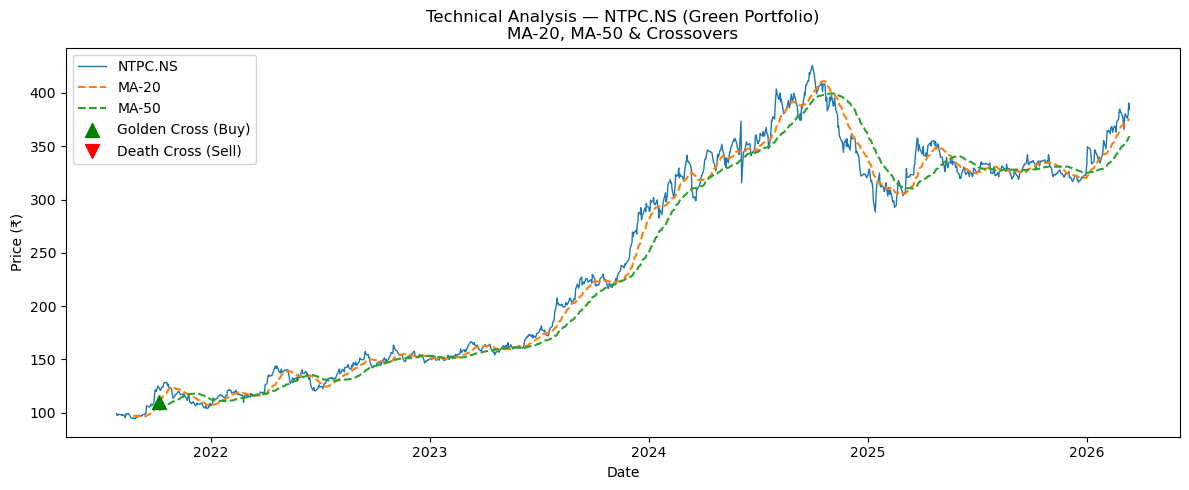


  Brown Portfolio — RELIANCE.NS
  Current Trend : BEARISH (Death Cross)
  Latest MA-20  : 1404.95  |  MA-50: 1433.90


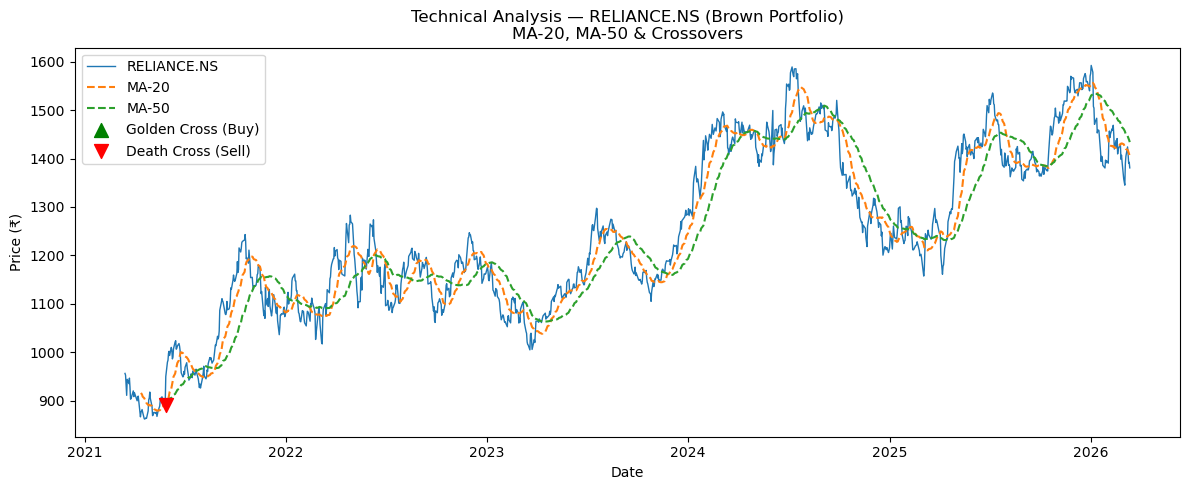


  Mixed Portfolio — NTPC.NS
  Current Trend : BULLISH (Golden Cross)
  Latest MA-20  : 376.12  |  MA-50: 359.54


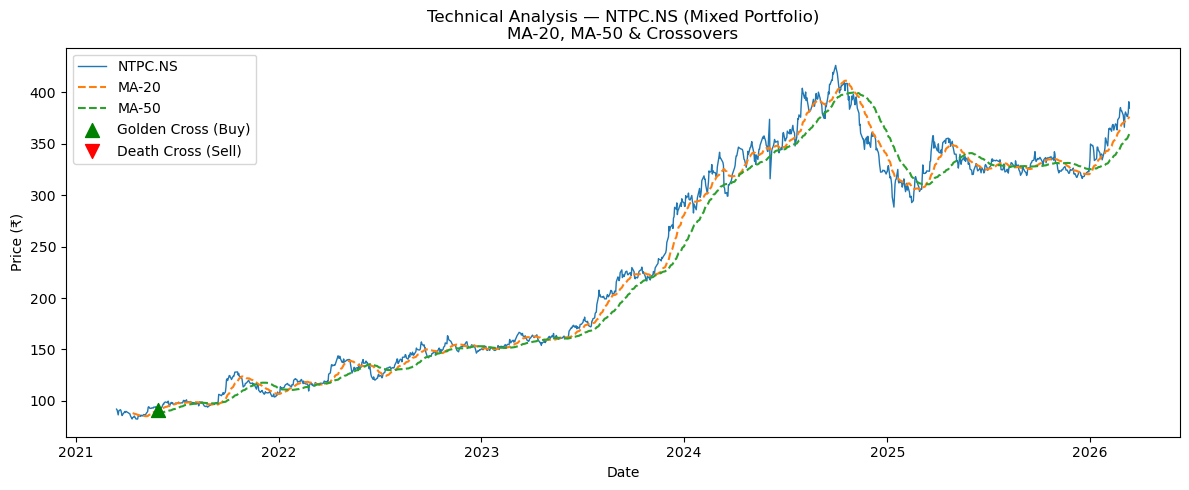


Technical Analysis complete.


In [26]:
# =============================================================================
# SECTION 2: TECHNICAL ANALYSIS
# Indicators: 20-day MA, 50-day MA
# Identifies: Bullish/Bearish trends, MA crossovers, trend strength & momentum
# =============================================================================

print("\n" + "=" * 65)
print("SECTION 2: TECHNICAL ANALYSIS")
print("=" * 65)

# Representative stock per portfolio
representative = {
    "Green": "NTPC.NS",
    "Brown": "RELIANCE.NS",
    "Mixed": "NTPC.NS"
}

for name, ticker in representative.items():
    data_ta = price_data[name][[ticker]].copy()
    data_ta.columns = [ticker]

    # --- Moving Averages ---
    data_ta['MA_20'] = data_ta[ticker].rolling(window=20).mean()
    data_ta['MA_50'] = data_ta[ticker].rolling(window=50).mean()

    # --- Crossover Signal: 1 = Golden Cross (Bullish), -1 = Death Cross (Bearish) ---
    data_ta['Signal'] = 0
    data_ta.loc[data_ta['MA_20'] > data_ta['MA_50'], 'Signal'] = 1
    data_ta.loc[data_ta['MA_20'] < data_ta['MA_50'], 'Signal'] = -1
    data_ta['Crossover'] = data_ta['Signal'].diff()

    # --- Trend Summary ---
    latest_signal = data_ta['Signal'].iloc[-1]
    trend = "BULLISH (Golden Cross)" if latest_signal == 1 else "BEARISH (Death Cross)"
    print(f"\n  {name} Portfolio — {ticker}")
    print(f"  Current Trend : {trend}")
    print(f"  Latest MA-20  : {data_ta['MA_20'].iloc[-1]:.2f}  |  MA-50: {data_ta['MA_50'].iloc[-1]:.2f}")

    # --- Price Trend & Moving Average Chart ---
    plt.figure(figsize=(12, 5))
    plt.plot(data_ta[ticker], label=ticker, linewidth=1)
    plt.plot(data_ta['MA_20'], label='MA-20', linestyle='--')
    plt.plot(data_ta['MA_50'], label='MA-50', linestyle='--')

    golden = data_ta[data_ta['Crossover'] == 1]
    plt.scatter(golden.index, golden['MA_20'], marker='^', color='green',
                s=100, label='Golden Cross (Buy)', zorder=5)

    death = data_ta[data_ta['Crossover'] == -1]
    plt.scatter(death.index, death['MA_20'], marker='v', color='red',
                s=100, label='Death Cross (Sell)', zorder=5)

    plt.title(f"Technical Analysis — {ticker} ({name} Portfolio)\nMA-20, MA-50 & Crossovers")
    plt.xlabel("Date")
    plt.ylabel("Price (₹)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"TA_{name}.png", dpi=150)
    plt.show()

print("\nTechnical Analysis complete.")


In [27]:
# =============================================================================
# SECTION 3: PORTFOLIO CONSTRUCTION
# Equal weights assumed: 10 stocks → 10% each
# =============================================================================

print("\n" + "=" * 65)
print("SECTION 3: PORTFOLIO CONSTRUCTION")
print("=" * 65)

equal_weights = {}

for name, tickers in portfolios.items():
    n = len(tickers)
    weights = np.array([1 / n] * n)
    equal_weights[name] = weights
    print(f"\n  {name} Portfolio — {n} stocks, weight each: {1/n:.2%}")
    for t, w in zip(tickers, weights):
        print(f"    {t:<20s}  {w:.2%}")



SECTION 3: PORTFOLIO CONSTRUCTION

  Green Portfolio — 10 stocks, weight each: 10.00%
    ADANIGREEN.NS         10.00%
    TATAPOWER.NS          10.00%
    SUZLON.NS             10.00%
    SJVN.NS               10.00%
    KPIGREEN.NS           10.00%
    NTPC.NS               10.00%
    TORNTPOWER.NS         10.00%
    INOXWIND.NS           10.00%
    CUMMINSIND.NS         10.00%
    BOSCHLTD.NS           10.00%

  Brown Portfolio — 10 stocks, weight each: 10.00%
    RELIANCE.NS           10.00%
    ONGC.NS               10.00%
    COALINDIA.NS          10.00%
    JSWSTEEL.NS           10.00%
    TATASTEEL.NS          10.00%
    ULTRACEMCO.NS         10.00%
    SAIL.NS               10.00%
    NMDC.NS               10.00%
    IOC.NS                10.00%
    BPCL.NS               10.00%

  Mixed Portfolio — 10 stocks, weight each: 10.00%
    ADANIGREEN.NS         10.00%
    TATAPOWER.NS          10.00%
    SUZLON.NS             10.00%
    SJVN.NS               10.00%
    NTPC.NS      

In [28]:
# =============================================================================
# SECTION 4: PORTFOLIO RISK AND RETURN
# Calculates: Expected Return, Variance, Standard Deviation, Sharpe Ratio
# Also includes Beta (CAPM) for interpreting risk-return characteristics.
# =============================================================================

print("\n" + "=" * 65)
print("SECTION 4: PORTFOLIO RISK AND RETURN")
print("=" * 65)

portfolio_stats = {}

for name, tickers in portfolios.items():
    returns = returns_data[name]
    weights = equal_weights[name]

    # Annualised expected return (252 trading days)
    expected_returns = returns.mean()
    port_return = np.dot(weights, expected_returns) * 252

    # Annualised covariance matrix & portfolio variance
    cov_matrix    = returns.cov() * 252
    port_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    port_std_dev  = np.sqrt(port_variance)

    # Sharpe Ratio
    sharpe = (port_return - RISK_FREE_RATE) / port_std_dev

    portfolio_stats[name] = {
        "return":   port_return,
        "variance": port_variance,
        "std_dev":  port_std_dev,
        "sharpe":   sharpe
    }

    print(f"\n  ── {name} Portfolio ──")
    print(f"  Expected Annual Return  : {port_return * 100:.2f}%")
    print(f"  Portfolio Variance      : {port_variance:.6f}")
    print(f"  Portfolio Std Deviation : {port_std_dev * 100:.2f}%")
    print(f"  Sharpe Ratio            : {sharpe:.4f}")

# ---------- Beta & CAPM — Expected Return per Stock ----------
print("\n" + "-" * 65)
print("  BETA & CAPM ANALYSIS")
print("-" * 65)

# Download Nifty 50 market returns
market_data    = yf.download(MARKET, start=START_DATE, end=END_DATE)['Close']
market_returns = market_data.pct_change().dropna()
market_return_annual = market_returns.mean().values[0] * 252

print(f"\n  Market: {MARKET}  |  Annualised Return: {market_return_annual * 100:.2f}%")

beta_results = {}

for name, tickers in portfolios.items():
    print(f"\n  ── {name} Portfolio ──")
    betas        = []
    capm_returns = []

    for stock in tickers:
        returns  = returns_data[name][stock]
        combined = pd.concat([returns, market_returns], axis=1).dropna()
        combined.columns = ['stock', 'market']

        X     = sm.add_constant(combined['market'])
        model = sm.OLS(combined['stock'], X).fit()
        beta  = model.params.iloc[1]

        exp_ret = RISK_FREE_RATE + beta * (market_return_annual - RISK_FREE_RATE)
        betas.append(beta)
        capm_returns.append(exp_ret)
        print(f"    {stock:<20s}  Beta: {beta:6.4f}  |  CAPM Return: {exp_ret*100:.2f}%")

    beta_results[name] = {
        "betas":        betas,
        "capm_returns": capm_returns,
        "avg_beta":     np.mean(betas)
    }
    print(f"  Portfolio Avg Beta: {np.mean(betas):.4f}")


[*********************100%***********************]  1 of 1 completed


SECTION 4: PORTFOLIO RISK AND RETURN

  ── Green Portfolio ──
  Expected Annual Return  : 38.54%
  Portfolio Variance      : 0.056614
  Portfolio Std Deviation : 23.79%
  Sharpe Ratio            : 1.3254

  ── Brown Portfolio ──
  Expected Annual Return  : 24.05%
  Portfolio Variance      : 0.046272
  Portfolio Std Deviation : 21.51%
  Sharpe Ratio            : 0.7925

  ── Mixed Portfolio ──
  Expected Annual Return  : 27.20%
  Portfolio Variance      : 0.045136
  Portfolio Std Deviation : 21.25%
  Sharpe Ratio            : 0.9510

-----------------------------------------------------------------
  BETA & CAPM ANALYSIS
-----------------------------------------------------------------

  Market: ^NSEI  |  Annualised Return: 9.89%

  ── Green Portfolio ──
    ADANIGREEN.NS         Beta: 1.3437  |  CAPM Return: 10.88%
    TATAPOWER.NS          Beta: 1.3518  |  CAPM Return: 10.90%
    SUZLON.NS             Beta: 1.2072  |  CAPM Return: 10.48%
    SJVN.NS               Beta: 1.1679  |  CA

    NMDC.NS               Beta: 1.2111  |  CAPM Return: 10.49%
    IOC.NS                Beta: 0.9733  |  CAPM Return: 9.81%
    BPCL.NS               Beta: 1.0089  |  CAPM Return: 9.91%
  Portfolio Avg Beta: 1.1524

  ── Mixed Portfolio ──
    ADANIGREEN.NS         Beta: 1.3413  |  CAPM Return: 10.87%
    TATAPOWER.NS          Beta: 1.3644  |  CAPM Return: 10.94%
    SUZLON.NS             Beta: 1.1951  |  CAPM Return: 10.45%
    SJVN.NS               Beta: 1.1274  |  CAPM Return: 10.25%
    NTPC.NS               Beta: 0.9650  |  CAPM Return: 9.78%
    RELIANCE.NS           Beta: 1.1322  |  CAPM Return: 10.27%
    ONGC.NS               Beta: 0.9314  |  CAPM Return: 9.69%
    COALINDIA.NS          Beta: 1.0082  |  CAPM Return: 9.91%
    JSWSTEEL.NS           Beta: 1.2513  |  CAPM Return: 10.61%
    ULTRACEMCO.NS         Beta: 0.9794  |  CAPM Return: 9.83%
  Portfolio Avg Beta: 1.1296



SECTION 5: OPTIMAL PORTFOLIO WEIGHTS

  ── Green Portfolio ──
  Max Sharpe     → Return: 51.48%  Vol: 24.74%  Sharpe: 1.7982
  Min Volatility → Return: 34.44%  Vol: 19.86%  Sharpe: 1.3814

  Max Sharpe Optimal Weights:
    ADANIGREEN.NS         0.78%
    TATAPOWER.NS          8.04%
    SUZLON.NS             31.19%
    SJVN.NS               3.22%
    KPIGREEN.NS           25.51%
    NTPC.NS               12.58%
    TORNTPOWER.NS         2.57%
    INOXWIND.NS           10.47%
    CUMMINSIND.NS         4.39%
    BOSCHLTD.NS           1.26%

  Min Volatility Optimal Weights:
    ADANIGREEN.NS         3.80%
    TATAPOWER.NS          34.66%
    SUZLON.NS             19.21%
    SJVN.NS               3.71%
    KPIGREEN.NS           8.23%
    NTPC.NS               17.46%
    TORNTPOWER.NS         5.41%
    INOXWIND.NS           0.17%
    CUMMINSIND.NS         0.72%
    BOSCHLTD.NS           6.63%


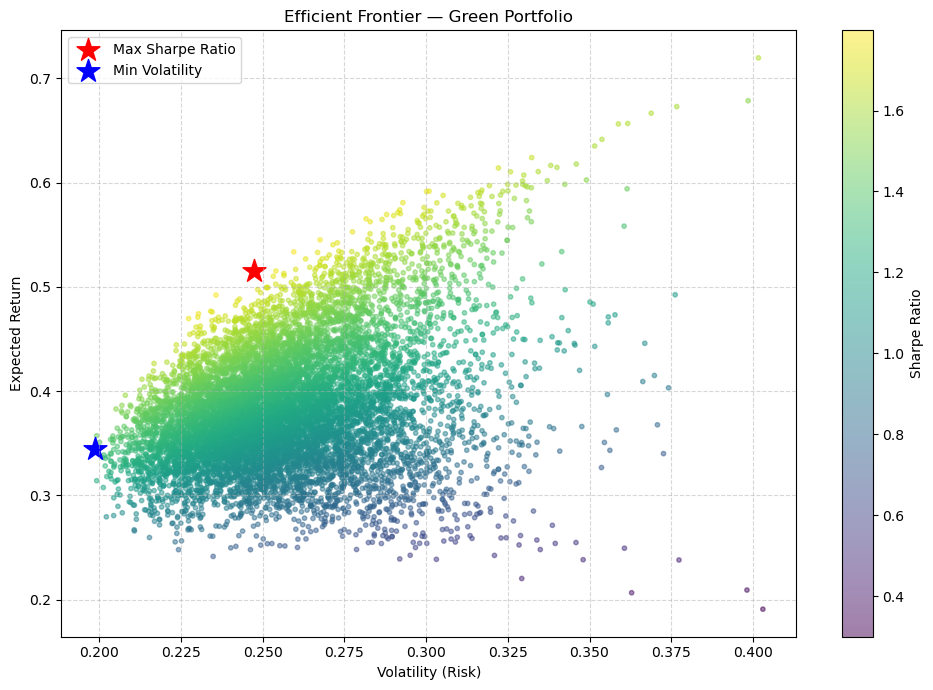


  ── Brown Portfolio ──
  Max Sharpe     → Return: 29.76%  Vol: 22.23%  Sharpe: 1.0239
  Min Volatility → Return: 19.00%  Vol: 17.91%  Sharpe: 0.6701

  Max Sharpe Optimal Weights:
    RELIANCE.NS           2.85%
    ONGC.NS               47.68%
    COALINDIA.NS          20.46%
    JSWSTEEL.NS           5.34%
    TATASTEEL.NS          6.39%
    ULTRACEMCO.NS         4.38%
    SAIL.NS               3.14%
    NMDC.NS               0.77%
    IOC.NS                0.42%
    BPCL.NS               8.58%

  Min Volatility Optimal Weights:
    RELIANCE.NS           3.95%
    ONGC.NS               4.15%
    COALINDIA.NS          17.25%
    JSWSTEEL.NS           8.02%
    TATASTEEL.NS          4.34%
    ULTRACEMCO.NS         6.36%
    SAIL.NS               25.63%
    NMDC.NS               1.00%
    IOC.NS                1.94%
    BPCL.NS               27.35%


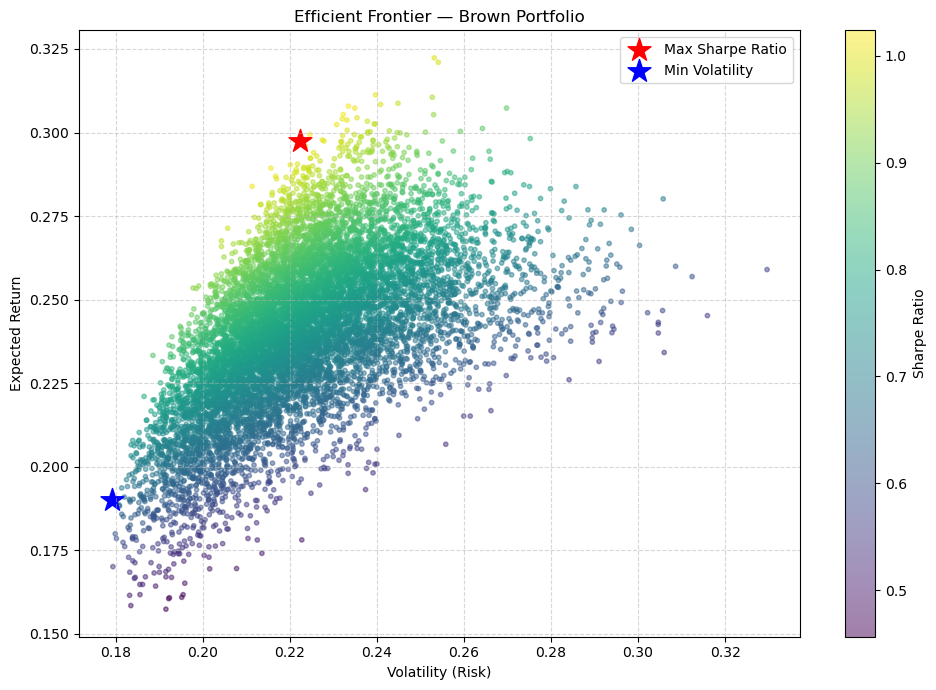


  ── Mixed Portfolio ──
  Max Sharpe     → Return: 36.03%  Vol: 23.29%  Sharpe: 1.2466
  Min Volatility → Return: 18.98%  Vol: 17.75%  Sharpe: 0.6750

  Max Sharpe Optimal Weights:
    ADANIGREEN.NS         0.43%
    TATAPOWER.NS          23.10%
    SUZLON.NS             5.57%
    SJVN.NS               21.68%
    NTPC.NS               16.29%
    RELIANCE.NS           0.03%
    ONGC.NS               5.53%
    COALINDIA.NS          19.67%
    JSWSTEEL.NS           4.19%
    ULTRACEMCO.NS         3.51%

  Min Volatility Optimal Weights:
    ADANIGREEN.NS         1.33%
    TATAPOWER.NS          11.78%
    SUZLON.NS             2.83%
    SJVN.NS               2.03%
    NTPC.NS               13.79%
    RELIANCE.NS           31.11%
    ONGC.NS               1.12%
    COALINDIA.NS          1.73%
    JSWSTEEL.NS           2.40%
    ULTRACEMCO.NS         31.90%


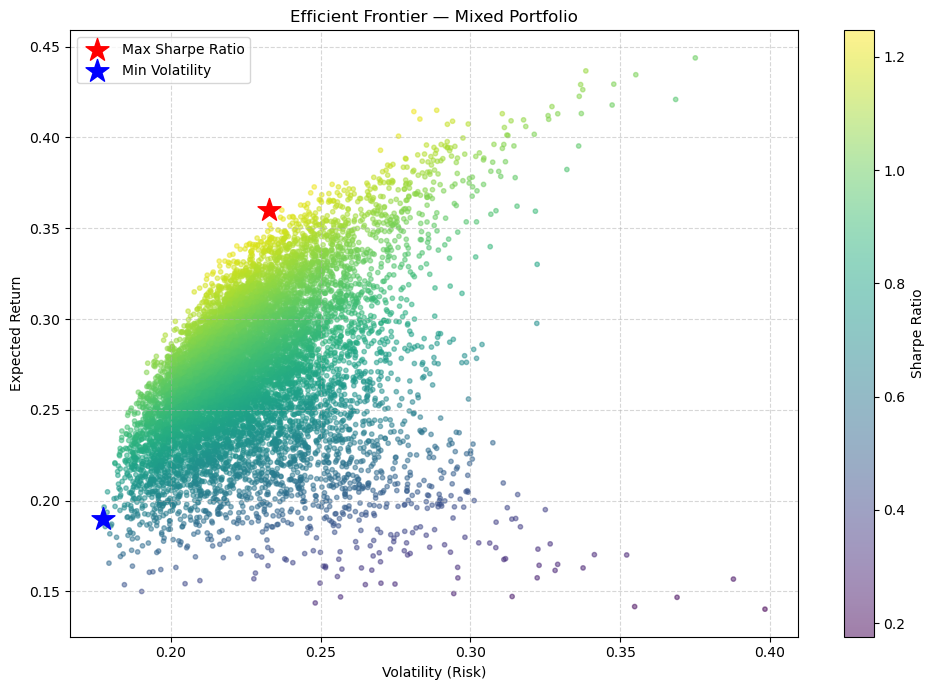


Portfolio Optimization complete.


In [29]:
# =============================================================================
# SECTION 5: OPTIMAL PORTFOLIO WEIGHTS
# Technique: Monte Carlo simulation of random weight combinations (10,000 runs)
# Identifies:
#   • Portfolio that maximises expected return for a given level of risk
#     (Maximum Sharpe Ratio portfolio)
#   • Portfolio that minimises variance (Minimum Volatility portfolio)
# =============================================================================

print("\n" + "=" * 65)
print("SECTION 5: OPTIMAL PORTFOLIO WEIGHTS")
print("=" * 65)

NUM_PORTFOLIOS = 10000
optimal_portfolios = {}

for name, tickers in portfolios.items():
    returns    = returns_data[name]
    exp_ret    = returns.mean()
    cov_matrix = returns.cov()

    port_returns    = []
    port_volatility = []
    port_sharpe     = []
    port_weights    = []

    np.random.seed(42)
    for _ in range(NUM_PORTFOLIOS):
        w     = np.random.dirichlet(np.ones(len(tickers)))
        p_ret = np.dot(w, exp_ret) * 252
        p_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix * 252, w)))
        p_sr  = (p_ret - RISK_FREE_RATE) / p_vol

        port_returns.append(p_ret)
        port_volatility.append(p_vol)
        port_sharpe.append(p_sr)
        port_weights.append(w)

    port_returns    = np.array(port_returns)
    port_volatility = np.array(port_volatility)
    port_sharpe     = np.array(port_sharpe)
    port_weights    = np.array(port_weights)

    max_sr_idx  = np.argmax(port_sharpe)
    min_vol_idx = np.argmin(port_volatility)

    optimal_portfolios[name] = {
        "max_sharpe": {
            "return":     port_returns[max_sr_idx],
            "volatility": port_volatility[max_sr_idx],
            "sharpe":     port_sharpe[max_sr_idx],
            "weights":    port_weights[max_sr_idx]
        },
        "min_volatility": {
            "return":     port_returns[min_vol_idx],
            "volatility": port_volatility[min_vol_idx],
            "sharpe":     port_sharpe[min_vol_idx],
            "weights":    port_weights[min_vol_idx]
        }
    }

    print(f"\n  ── {name} Portfolio ──")
    print(f"  Max Sharpe     → Return: {port_returns[max_sr_idx]*100:.2f}%  "
          f"Vol: {port_volatility[max_sr_idx]*100:.2f}%  "
          f"Sharpe: {port_sharpe[max_sr_idx]:.4f}")
    print(f"  Min Volatility → Return: {port_returns[min_vol_idx]*100:.2f}%  "
          f"Vol: {port_volatility[min_vol_idx]*100:.2f}%  "
          f"Sharpe: {port_sharpe[min_vol_idx]:.4f}")

    print(f"\n  Max Sharpe Optimal Weights:")
    for t, w in zip(tickers, port_weights[max_sr_idx]):
        print(f"    {t:<20s}  {w:.2%}")

    print(f"\n  Min Volatility Optimal Weights:")
    for t, w in zip(tickers, port_weights[min_vol_idx]):
        print(f"    {t:<20s}  {w:.2%}")

    # --- Efficient Frontier Plot ---
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(port_volatility, port_returns,
                          c=port_sharpe, cmap='viridis', alpha=0.5, s=10)
    plt.colorbar(scatter, label='Sharpe Ratio')
    plt.scatter(port_volatility[max_sr_idx], port_returns[max_sr_idx],
                color='red',  marker='*', s=300, label='Max Sharpe Ratio')
    plt.scatter(port_volatility[min_vol_idx], port_returns[min_vol_idx],
                color='blue', marker='*', s=300, label='Min Volatility')
    plt.title(f"Efficient Frontier — {name} Portfolio")
    plt.xlabel("Volatility (Risk)")
    plt.ylabel("Expected Return")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"EF_{name}.png", dpi=150)
    plt.show()

print("\nPortfolio Optimization complete.")



SECTION 6: VALUE AT RISK — HISTORICAL METHOD (95%)

  ── Green Portfolio — Individual Stock VaR ──
    ADANIGREEN.NS         VaR: -4.65%  |  ₹4,652.98
    TATAPOWER.NS          VaR: -3.20%  |  ₹3,203.36
    SUZLON.NS             VaR: -4.77%  |  ₹4,771.04
    SJVN.NS               VaR: -3.46%  |  ₹3,457.40
    KPIGREEN.NS           VaR: -5.07%  |  ₹5,072.41
    NTPC.NS               VaR: -2.20%  |  ₹2,198.07
    NHPC.NS               VaR: -2.83%  |  ₹2,830.82
    POWERGRID.NS          VaR: -2.32%  |  ₹2,321.78
    THERMAX.NS            VaR: -3.30%  |  ₹3,296.05
    EXIDEIND.NS           VaR: -2.59%  |  ₹2,592.80

  ── Green Portfolio — Portfolio VaR ──
  95% Daily Historical VaR (Return) : -0.0231  (-2.31%)
  95% Daily Historical VaR (₹)      : ₹23,078.00  (on ₹1,000,000 portfolio)


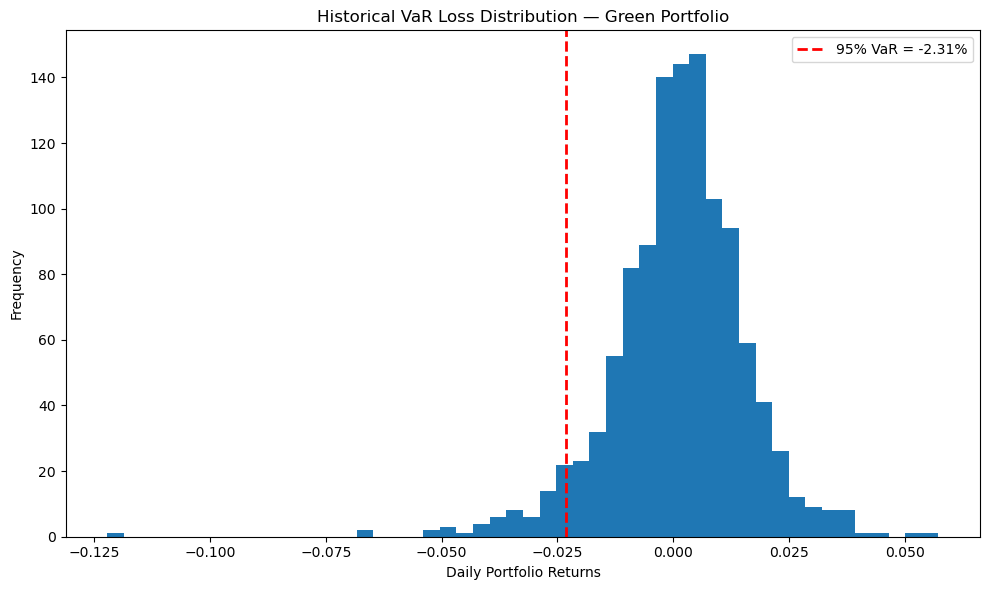


  ── Brown Portfolio — Individual Stock VaR ──
    RELIANCE.NS           VaR: -2.15%  |  ₹2,148.59
    ONGC.NS               VaR: -2.70%  |  ₹2,701.56
    COALINDIA.NS          VaR: -2.58%  |  ₹2,581.41
    JSWSTEEL.NS           VaR: -2.70%  |  ₹2,697.64
    ULTRACEMCO.NS         VaR: -2.21%  |  ₹2,213.99
    HINDPETRO.NS          VaR: -3.45%  |  ₹3,451.44
    GAIL.NS               VaR: -2.90%  |  ₹2,901.05
    VEDL.NS               VaR: -3.55%  |  ₹3,548.44
    HINDALCO.NS           VaR: -3.59%  |  ₹3,593.09
    SAIL.NS               VaR: -4.08%  |  ₹4,075.55

  ── Brown Portfolio — Portfolio VaR ──
  95% Daily Historical VaR (Return) : -0.0224  (-2.24%)
  95% Daily Historical VaR (₹)      : ₹22,415.91  (on ₹1,000,000 portfolio)


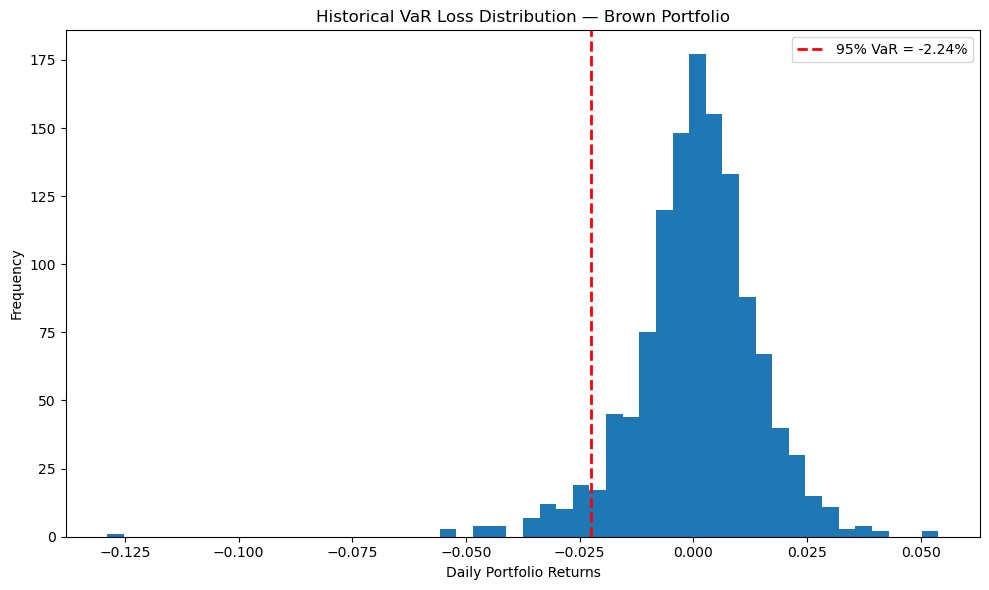


  ── Mixed Portfolio — Individual Stock VaR ──
    ADANIGREEN.NS         VaR: -4.72%  |  ₹4,720.94
    TATAPOWER.NS          VaR: -3.22%  |  ₹3,215.75
    SUZLON.NS             VaR: -4.81%  |  ₹4,810.40
    SJVN.NS               VaR: -3.37%  |  ₹3,369.01
    NTPC.NS               VaR: -2.26%  |  ₹2,258.13
    RELIANCE.NS           VaR: -2.15%  |  ₹2,148.59
    ONGC.NS               VaR: -2.70%  |  ₹2,701.56
    COALINDIA.NS          VaR: -2.58%  |  ₹2,581.41
    JSWSTEEL.NS           VaR: -2.70%  |  ₹2,697.64
    ULTRACEMCO.NS         VaR: -2.21%  |  ₹2,213.99

  ── Mixed Portfolio — Portfolio VaR ──
  95% Daily Historical VaR (Return) : -0.0220  (-2.20%)
  95% Daily Historical VaR (₹)      : ₹22,015.61  (on ₹1,000,000 portfolio)


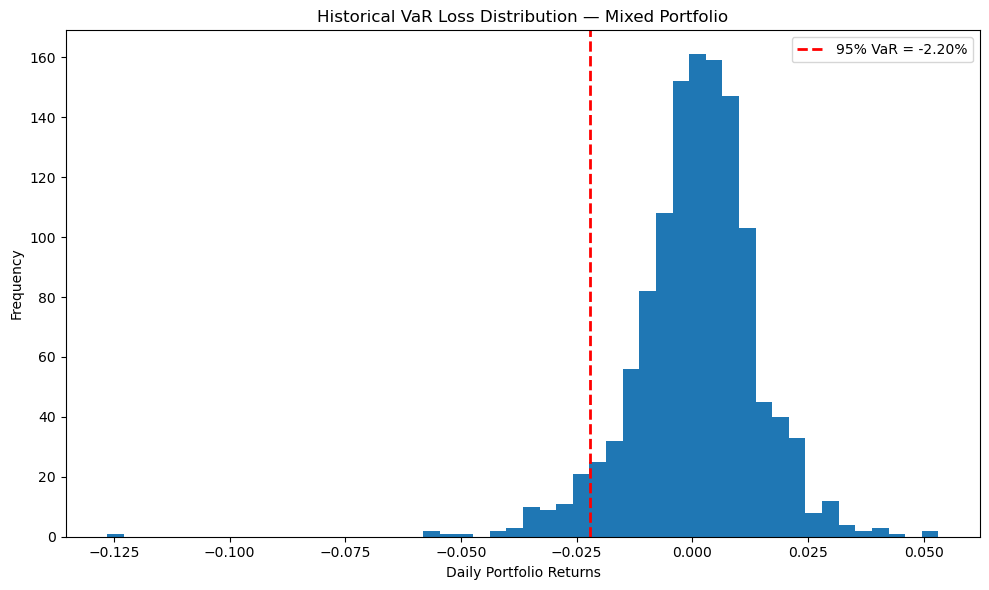


Historical VaR complete.


In [21]:
# =============================================================================
# SECTION 6: VALUE AT RISK (VaR)
# Method: Historical VaR at 95% confidence level
# Applied to: Individual stocks and each portfolio
# =============================================================================

print("\n" + "=" * 65)
print("SECTION 6: VALUE AT RISK — HISTORICAL METHOD (95%)")
print("=" * 65)

var_results = {}

for name, tickers in portfolios.items():
    data    = price_data[name]
    weights = equal_weights[name]

    # Log returns
    log_returns = np.log(data / data.shift(1)).dropna()

    # --- Individual Stock VaR ---
    print(f"\n  ── {name} Portfolio — Individual Stock VaR ──")
    for ticker in tickers:
        stock_var = np.percentile(log_returns[ticker], (1 - CONFIDENCE_LEVEL) * 100)
        monetary  = PORTFOLIO_VALUE / len(tickers) * abs(stock_var)
        print(f"    {ticker:<20s}  VaR: {stock_var*100:.2f}%  |  ₹{monetary:,.2f}")

    # --- Portfolio VaR ---
    portfolio_returns = log_returns.dot(weights)
    VaR_return   = np.percentile(portfolio_returns, (1 - CONFIDENCE_LEVEL) * 100)
    monetary_VaR = PORTFOLIO_VALUE * abs(VaR_return)

    var_results[name] = {
        "VaR_return":   VaR_return,
        "monetary_VaR": monetary_VaR
    }

    print(f"\n  ── {name} Portfolio — Portfolio VaR ──")
    print(f"  95% Daily Historical VaR (Return) : {VaR_return:.4f}  ({VaR_return*100:.2f}%)")
    print(f"  95% Daily Historical VaR (₹)      : ₹{monetary_VaR:,.2f}  "
          f"(on ₹{PORTFOLIO_VALUE:,} portfolio)")

    # --- VaR Loss Distribution Chart ---
    plt.figure(figsize=(10, 6))
    plt.hist(portfolio_returns, bins=50)
    plt.axvline(VaR_return, color='r', linestyle='dashed', linewidth=2,
                label=f'95% VaR = {VaR_return*100:.2f}%')
    plt.title(f"Historical VaR Loss Distribution — {name} Portfolio")
    plt.xlabel("Daily Portfolio Returns")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"VaR_{name}.png", dpi=150)
    plt.show()

print("\nHistorical VaR complete.")



SECTION 7: MONTE CARLO SIMULATION

  Part A: Single-Stock GBM Price Path Simulation
  ------------------------------------------------------------

  ── Green Portfolio  |  Stock: NTPC.NS ──
  Starting Price     : ₹384.45
  Mean Simulated (T) : ₹520.95
  5th  Percentile    : ₹333.61
  95th Percentile    : ₹783.49
  Probability Gain   : 85.60%
  Probability Loss   : 14.40%


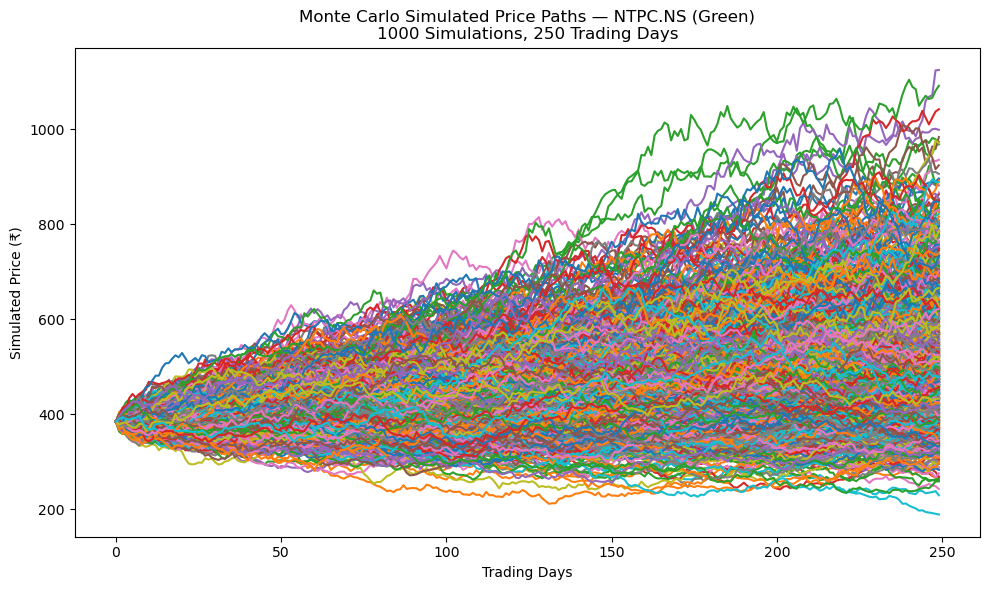

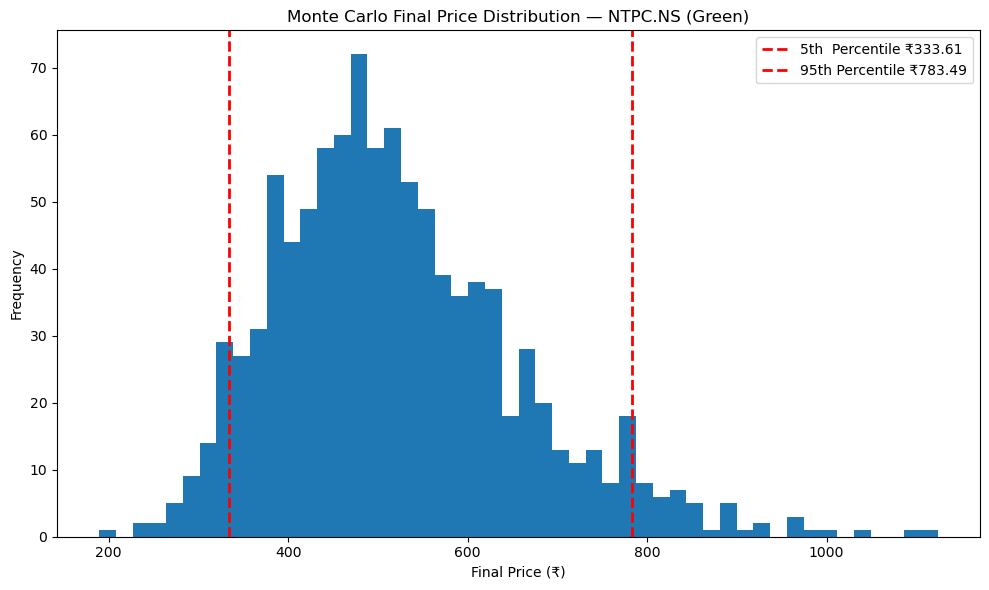


  ── Brown Portfolio  |  Stock: RELIANCE.NS ──
  Starting Price     : ₹1,380.70
  Mean Simulated (T) : ₹1,488.74
  5th  Percentile    : ₹1,023.88
  95th Percentile    : ₹2,108.82
  Probability Gain   : 57.90%
  Probability Loss   : 42.10%


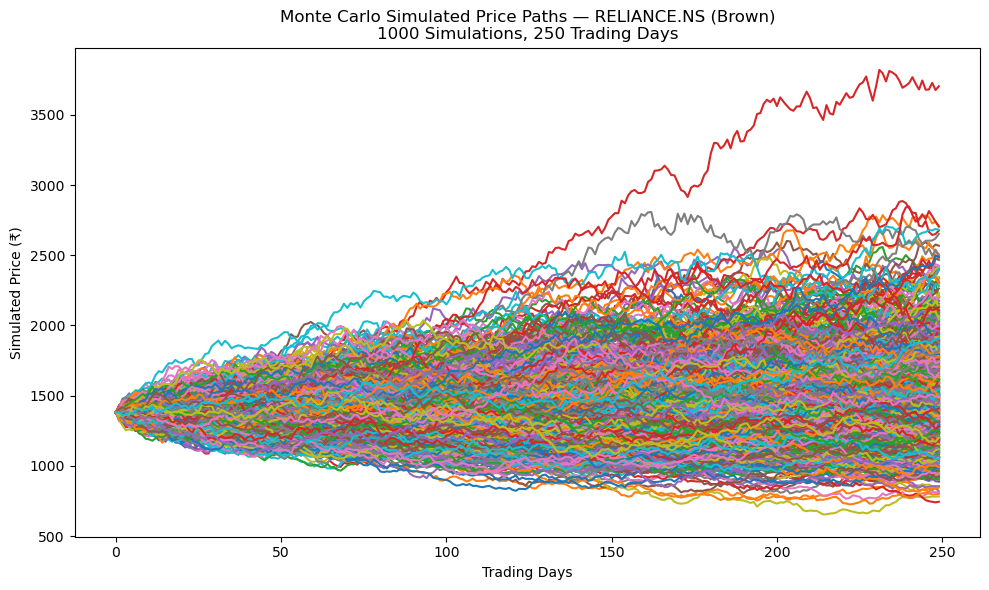

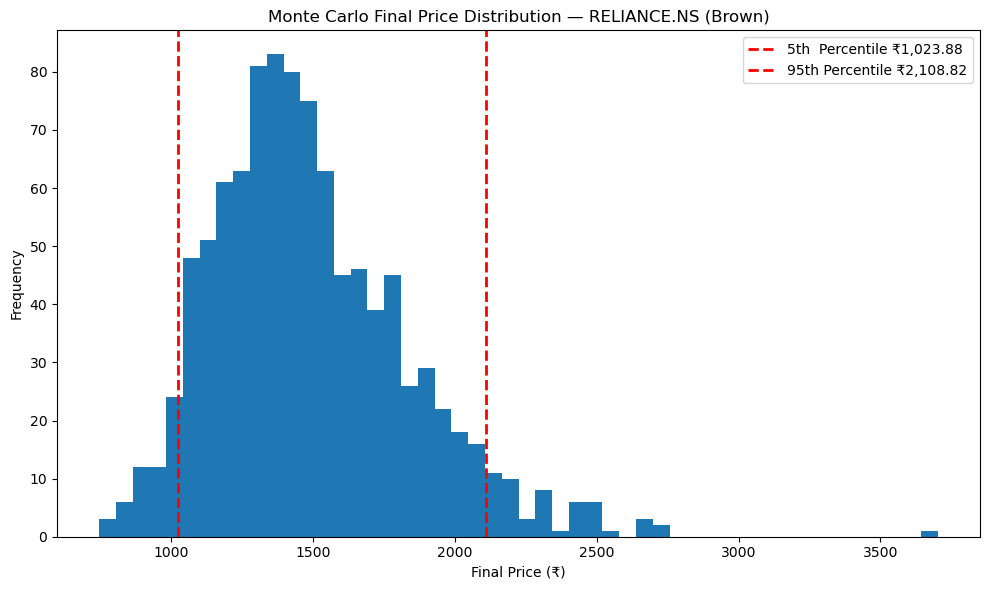


  ── Mixed Portfolio  |  Stock: SJVN.NS ──
  Starting Price     : ₹69.89
  Mean Simulated (T) : ₹89.55
  5th  Percentile    : ₹42.36
  95th Percentile    : ₹160.12
  Probability Gain   : 63.60%
  Probability Loss   : 36.40%


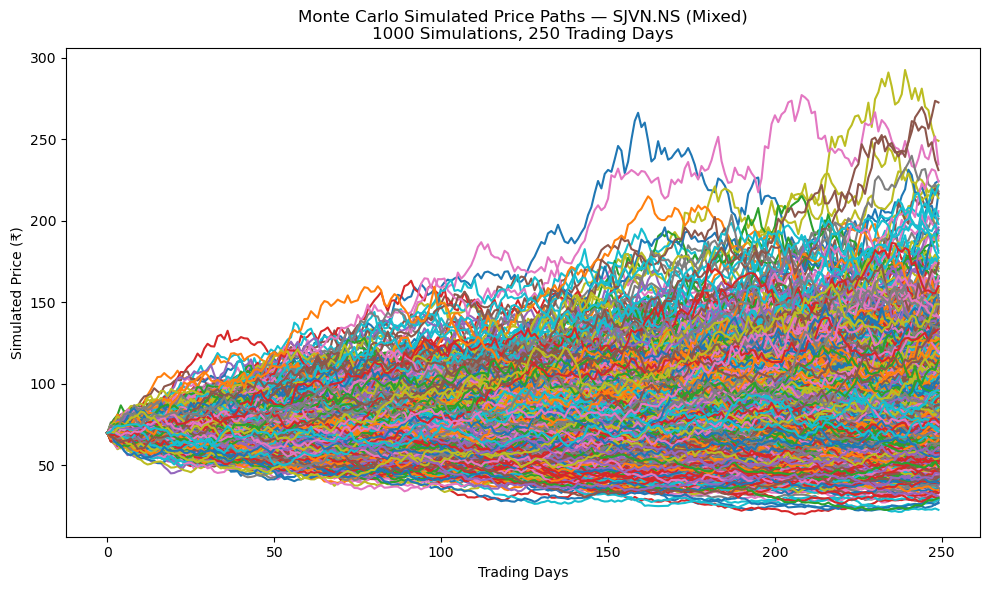

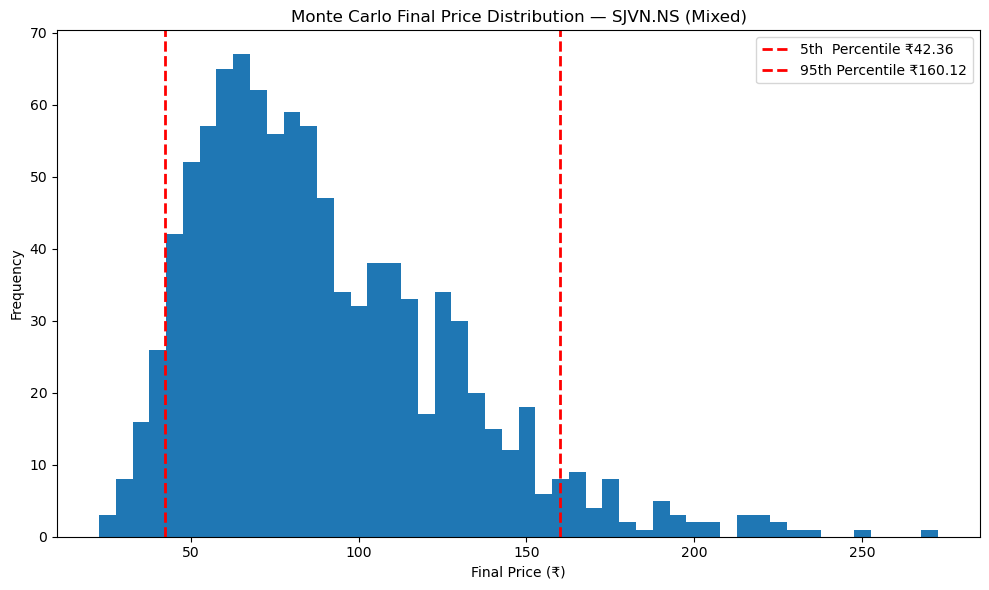


  Single-Stock Monte Carlo complete.

  Part B: Monte Carlo Portfolio VaR — Cholesky Decomposition
  ------------------------------------------------------------

  ── Green Portfolio ──
  Simulations               : 10,000
  95% MC VaR (Return)       : 2.36%
  95% MC VaR (₹)            : ₹23,626.19
  Expected Shortfall (₹)    : ₹29,616.51


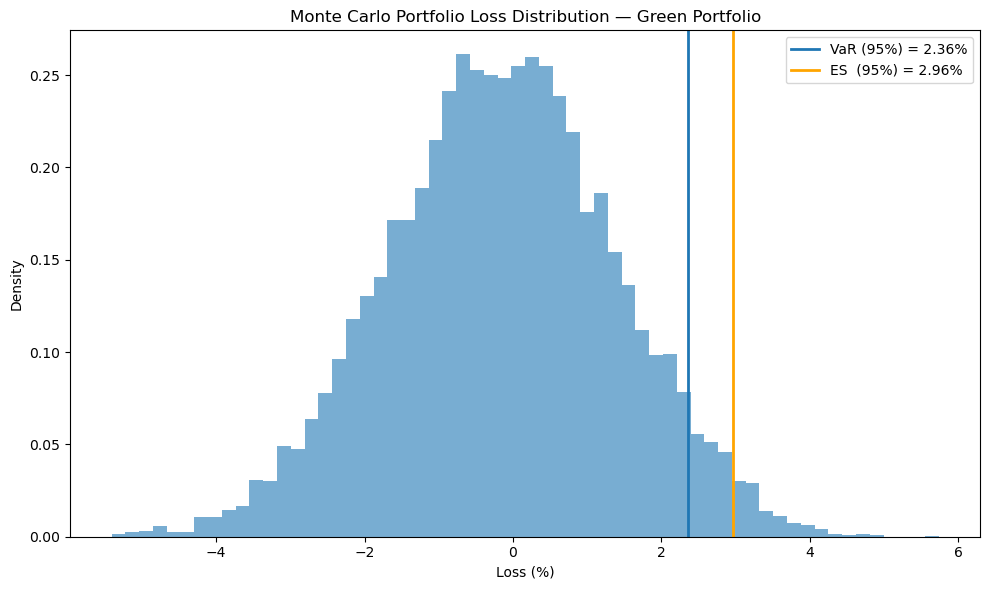


  ── Brown Portfolio ──
  Simulations               : 10,000
  95% MC VaR (Return)       : 2.20%
  95% MC VaR (₹)            : ₹21,988.35
  Expected Shortfall (₹)    : ₹27,479.49


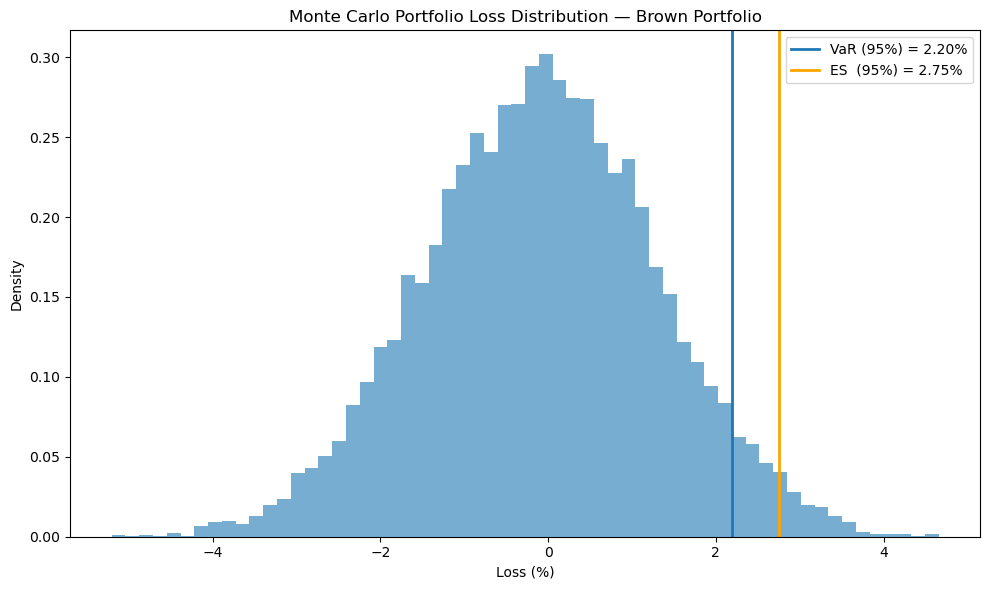


  ── Mixed Portfolio ──
  Simulations               : 10,000
  95% MC VaR (Return)       : 2.13%
  95% MC VaR (₹)            : ₹21,346.88
  Expected Shortfall (₹)    : ₹26,470.48


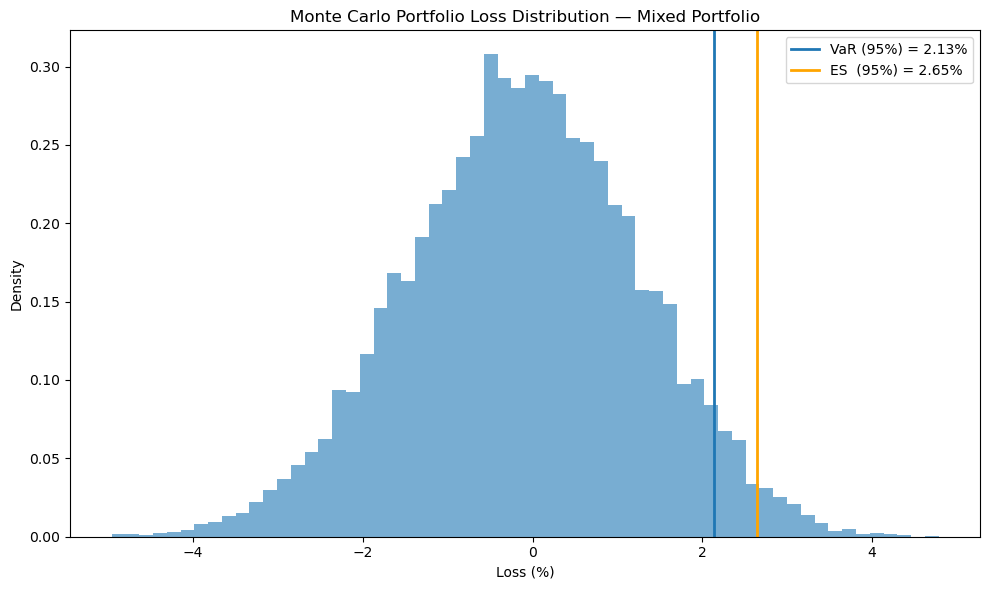


Monte Carlo Simulation complete.


In [30]:
# =============================================================================
# SECTION 7: MONTE CARLO SIMULATION
# Part A — Single-Stock GBM Price Path Simulation
#   • Estimates probability of gain or loss
#   • Compares simulated outcomes with recent price movements
#   • Interprets potential future volatility and risk
# Part B — Portfolio VaR via Cholesky Decomposition
# =============================================================================

print("\n" + "=" * 65)
print("SECTION 7: MONTE CARLO SIMULATION")
print("=" * 65)

# ── Part A: Single-Stock GBM ─────────────────────────────────────────────────
print("\n  Part A: Single-Stock GBM Price Path Simulation")
print("  " + "-" * 60)

mc_stocks = {
    "Green": "NTPC.NS",
    "Brown": "RELIANCE.NS",
    "Mixed": "SJVN.NS"
}

mc_results = {}

for name, ticker in mc_stocks.items():
    data_mc = price_data[name][[ticker]].copy()
    data_mc.columns = [ticker]

    log_returns = np.log(1 + data_mc.pct_change())
    u     = log_returns.mean()
    var   = log_returns.var()
    drift = u - (0.5 * var)
    stdev = log_returns.std()

    # GBM daily returns
    daily_returns = np.exp(
        drift.values + stdev.values * norm.ppf(
            np.random.rand(MC_T_INTERVALS, MC_ITERATIONS)
        )
    )

    # Build price paths
    S0 = data_mc.iloc[-1].values[0]
    price_list    = np.zeros_like(daily_returns)
    price_list[0] = S0
    for t in range(1, MC_T_INTERVALS):
        price_list[t] = price_list[t - 1] * daily_returns[t]

    final_prices = price_list[-1]
    p5  = np.percentile(final_prices, 5)
    p95 = np.percentile(final_prices, 95)
    prob_gain = np.mean(final_prices > S0) * 100
    prob_loss = np.mean(final_prices < S0) * 100

    mc_results[name] = {
        "mean_price": np.mean(final_prices),
        "p5": p5, "p95": p95,
        "prob_gain": prob_gain, "prob_loss": prob_loss
    }

    print(f"\n  ── {name} Portfolio  |  Stock: {ticker} ──")
    print(f"  Starting Price     : ₹{S0:,.2f}")
    print(f"  Mean Simulated (T) : ₹{np.mean(final_prices):,.2f}")
    print(f"  5th  Percentile    : ₹{p5:,.2f}")
    print(f"  95th Percentile    : ₹{p95:,.2f}")
    print(f"  Probability Gain   : {prob_gain:.2f}%")
    print(f"  Probability Loss   : {prob_loss:.2f}%")

    # Monte Carlo simulated price paths chart
    plt.figure(figsize=(10, 6))
    plt.plot(price_list)
    plt.title(f"Monte Carlo Simulated Price Paths — {ticker} ({name})\n"
              f"{MC_ITERATIONS} Simulations, {MC_T_INTERVALS} Trading Days")
    plt.xlabel("Trading Days")
    plt.ylabel("Simulated Price (₹)")
    plt.tight_layout()
    plt.savefig(f"MC_paths_{name}.png", dpi=150)
    plt.show()

    # Final price distribution chart
    plt.figure(figsize=(10, 6))
    plt.hist(final_prices, bins=50)
    plt.axvline(p5,  color='r', linestyle='dashed', linewidth=2, label=f'5th  Percentile ₹{p5:,.2f}')
    plt.axvline(p95, color='r', linestyle='dashed', linewidth=2, label=f'95th Percentile ₹{p95:,.2f}')
    plt.title(f"Monte Carlo Final Price Distribution — {ticker} ({name})")
    plt.xlabel("Final Price (₹)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"MC_dist_{name}.png", dpi=150)
    plt.show()

print("\n  Single-Stock Monte Carlo complete.")

# ── Part B: Portfolio VaR via Cholesky Decomposition ─────────────────────────
print("\n  Part B: Monte Carlo Portfolio VaR — Cholesky Decomposition")
print("  " + "-" * 60)

mc_var_results = {}

for name, tickers in portfolios.items():
    returns    = returns_data[name]
    weights    = equal_weights[name]

    mu         = returns.mean().values
    cov_matrix = returns.cov().values
    L          = np.linalg.cholesky(cov_matrix)

    np.random.seed(42)
    simulated_portfolio_returns = []

    for i in range(MC_SIMULATIONS):
        Z                 = np.random.normal(size=len(tickers))
        correlated_Z      = L @ Z
        simulated_returns = mu + correlated_Z
        portfolio_return  = np.dot(weights, simulated_returns)
        simulated_portfolio_returns.append(portfolio_return)

    simulated_portfolio_returns = np.array(simulated_portfolio_returns)

    portfolio_losses = -simulated_portfolio_returns
    VaR = np.percentile(portfolio_losses, CONFIDENCE_LEVEL * 100)
    ES  = portfolio_losses[portfolio_losses >= VaR].mean()

    monetary_VaR_mc = PORTFOLIO_VALUE * VaR
    monetary_ES_mc  = PORTFOLIO_VALUE * ES

    mc_var_results[name] = {
        "VaR": VaR, "ES": ES,
        "monetary_VaR": monetary_VaR_mc, "monetary_ES": monetary_ES_mc
    }

    print(f"\n  ── {name} Portfolio ──")
    print(f"  Simulations               : {MC_SIMULATIONS:,}")
    print(f"  95% MC VaR (Return)       : {VaR*100:.2f}%")
    print(f"  95% MC VaR (₹)            : ₹{monetary_VaR_mc:,.2f}")
    print(f"  Expected Shortfall (₹)    : ₹{monetary_ES_mc:,.2f}")

    # Portfolio loss distribution chart
    plt.figure(figsize=(10, 6))
    plt.hist(portfolio_losses * 100, bins=60, density=True, alpha=0.6)
    plt.axvline(VaR * 100, linewidth=2, label=f'VaR (95%) = {VaR*100:.2f}%')
    plt.axvline(ES  * 100, linewidth=2, label=f'ES  (95%) = {ES*100:.2f}%', color='orange')
    plt.title(f"Monte Carlo Portfolio Loss Distribution — {name} Portfolio")
    plt.xlabel("Loss (%)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"MC_VaR_{name}.png", dpi=150)
    plt.show()

print("\nMonte Carlo Simulation complete.")



SECTION 8: VISUALIZATION AND INTERPRETATION


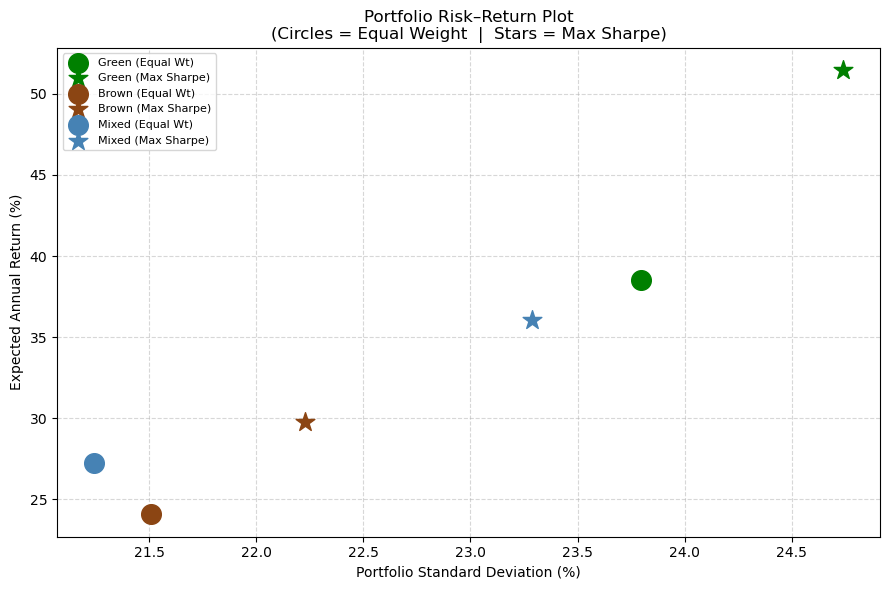


Portfolio    Exp Return    Std Dev   Sharpe   Avg Beta     Hist VaR     MC VaR
------------------------------------------------------------------------------
Green            38.54%     23.79%   1.3254     1.1110       -2.31%      2.36%
Brown            24.05%     21.51%   0.7925     1.1524       -2.24%      2.20%
Mixed            27.20%     21.25%   0.9510     1.1296       -2.20%      2.13%
------------------------------------------------------------------------------

--- Optimal Portfolios (Max Sharpe Weights) ---

  Green Portfolio  | Return: 51.48%  | Volatility: 24.74%  | Sharpe: 1.7982

  Brown Portfolio  | Return: 29.76%  | Volatility: 22.23%  | Sharpe: 1.0239

  Mixed Portfolio  | Return: 36.03%  | Volatility: 23.29%  | Sharpe: 1.2466

--- Monte Carlo Single-Stock Outlook ---
  Green (NTPC.NS):  Prob Gain: 85.6%  Prob Loss: 14.4%  5th/95th: ₹334 / ₹783
  Brown (RELIANCE.NS):  Prob Gain: 57.9%  Prob Loss: 42.1%  5th/95th: ₹1,024 / ₹2,109
  Mixed (SJVN.NS):  Prob Gain: 63.6%  P

In [32]:
# =============================================================================
# SECTION 8: VISUALIZATION AND INTERPRETATION
# Presents a comparative summary and portfolio risk-return plot across all
# three portfolios. Interprets risk characteristics, return potential, and
# diversification benefits.
# =============================================================================

print("\n" + "=" * 65)
print("SECTION 8: VISUALIZATION AND INTERPRETATION")
print("=" * 65)

# --- Portfolio Risk-Return Comparison Plot ---
fig, ax = plt.subplots(figsize=(9, 6))
colors  = {"Green": "green", "Brown": "saddlebrown", "Mixed": "steelblue"}

for name in portfolios:
    st = portfolio_stats[name]
    ax.scatter(st['std_dev'] * 100, st['return'] * 100,
               color=colors[name], s=200, zorder=5, label=f"{name} (Equal Wt)")

    opt = optimal_portfolios[name]['max_sharpe']
    ax.scatter(opt['volatility'] * 100, opt['return'] * 100,
               color=colors[name], s=200, marker='*', zorder=5,
               label=f"{name} (Max Sharpe)")

ax.set_xlabel("Portfolio Standard Deviation (%)")
ax.set_ylabel("Expected Annual Return (%)")
ax.set_title("Portfolio Risk–Return Plot\n(Circles = Equal Weight  |  Stars = Max Sharpe)")
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("RiskReturn_Comparison.png", dpi=150)
plt.show()

# --- Tabular Summary ---
print(f"\n{'Portfolio':<10} {'Exp Return':>12} {'Std Dev':>10} {'Sharpe':>8} "
      f"{'Avg Beta':>10} {'Hist VaR':>12} {'MC VaR':>10}")
print("-" * 78)

for name in portfolios:
    st  = portfolio_stats[name]
    br  = beta_results[name]
    vr  = var_results[name]
    mvr = mc_var_results[name]

    print(f"{name:<10} "
          f"{st['return']*100:>11.2f}% "
          f"{st['std_dev']*100:>9.2f}% "
          f"{st['sharpe']:>8.4f} "
          f"{br['avg_beta']:>10.4f} "
          f"{vr['VaR_return']*100:>11.2f}% "
          f"{mvr['VaR']*100:>9.2f}%")

print("-" * 78)

# --- Optimal Portfolio Summary ---
print("\n--- Optimal Portfolios (Max Sharpe Weights) ---")
for name in portfolios:
    opt = optimal_portfolios[name]['max_sharpe']
    print(f"\n  {name} Portfolio  "
          f"| Return: {opt['return']*100:.2f}%  "
          f"| Volatility: {opt['volatility']*100:.2f}%  "
          f"| Sharpe: {opt['sharpe']:.4f}")

# --- Monte Carlo Outlook ---
print("\n--- Monte Carlo Single-Stock Outlook ---")
mc_stocks = {"Green": "NTPC.NS", "Brown": "RELIANCE.NS", "Mixed": "SJVN.NS"}
for name, ticker in mc_stocks.items():
    mc = mc_results[name]
    print(f"  {name} ({ticker}):  "
          f"Prob Gain: {mc['prob_gain']:.1f}%  "
          f"Prob Loss: {mc['prob_loss']:.1f}%  "
          f"5th/95th: ₹{mc['p5']:,.0f} / ₹{mc['p95']:,.0f}")


print("\n" + "-" * 65)
print("ASSIGNMENT ANALYSIS COMPLETE")

